## **Customer shopping**

### Contents
1. Load data and check size
2. Drop unused columns
3. Check missing values, duplicates, and dtypes
4. Split by Gender
5. EDA — Item Purchased, Size, Category, Review Rating, Purchase Amount
6. Multivariate — correlation heatmap
7. Feature engineering — dummy variables, scaling, binning
8. Summary

In [4]:
! pip install --upgrade pip
! pip install matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 11.8 MB/s  0:00:00eta 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 26.1.2
    Uninstalling pip-26.1.2:
      Successfully uninstalled pip-26.1.2


In [ ]:
df = pd.read_csv('shopping_trends (1).csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [6]:
df.shape


(3900, 19)

In [7]:
df = df.drop(columns=['Customer ID'])
df.head()


,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


### **Data quality**

Check dtypes, missing values, and duplicate rows before plotting.

In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       3900 non-null   int64  
 1   Gender                    3900 non-null   str    
 2   Item Purchased            3900 non-null   str    
 3   Category                  3900 non-null   str    
 4   Purchase Amount (USD)     3900 non-null   int64  
 5   Location                  3900 non-null   str    
 6   Size                      3900 non-null   str    
 7   Color                     3900 non-null   str    
 8   Season                    3900 non-null   str    
 9   Review Rating             3900 non-null   float64
 10  Subscription Status       3900 non-null   str    
 11  Payment Method            3900 non-null   str    
 12  Shipping Type             3900 non-null   str    
 13  Discount Applied          3900 non-null   str    
 14  Promo Code Used    

In [10]:
df.isnull().sum()


Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [12]:
df.duplicated().sum()


np.int64(0)

In [13]:
df.describe()


,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


In [14]:
male_df = df[df['Gender'] == 'Male'].copy()
female_df = df[df['Gender'] == 'Female'].copy()

male_df.shape, female_df.shape


((2652, 18), (1248, 18))

## **EDA**

### **Item Purchased**

In [15]:
top_item_m = male_df['Item Purchased'].value_counts().reset_index()
top_item_f = female_df['Item Purchased'].value_counts().reset_index()
top_item = df['Item Purchased'].value_counts().reset_index()

print("Top items - All customers")
display(top_item.head(10))

print("Top items - Males")
display(top_item_m.head(10))

print("Top items - Females")
display(top_item_f.head(10))


Top items - All customers


,Item Purchased,count
0,Blouse,171
1,Pants,171
2,Jewelry,171
3,Shirt,169
4,Dress,166
5,Sweater,164
6,Jacket,163
7,Coat,161
8,Sunglasses,161
9,Belt,161


Top items - Males


,Item Purchased,count
0,Pants,123
1,Jewelry,119
2,Sweater,114
3,Coat,114
4,Dress,114
5,Scarf,112
6,Shirt,110
7,Shorts,109
8,Skirt,109
9,Jacket,109


Top items - Females


,Item Purchased,count
0,Blouse,66
1,Sandals,59
2,Shirt,59
3,Handbag,58
4,Socks,58
5,Sunglasses,56
6,Belt,55
7,Jacket,54
8,Dress,52
9,Jewelry,52


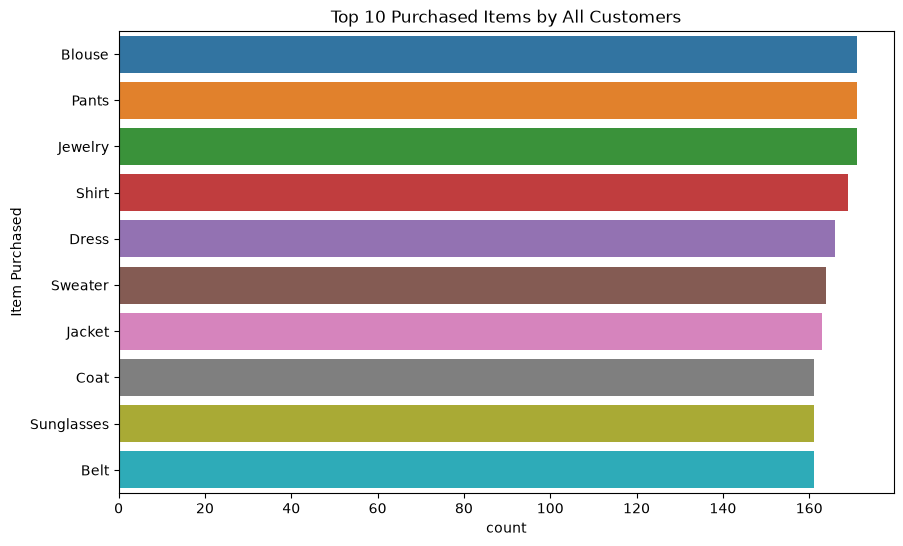

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_item.head(10),
    y='Item Purchased',
    x='count',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items by All Customers")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()


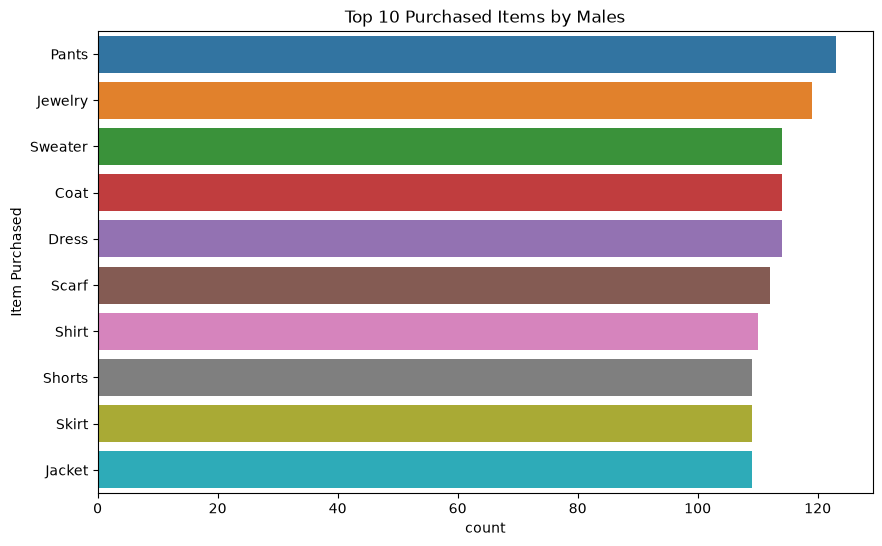

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_item_m.head(10),
    y='Item Purchased',
    x='count',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items by Males")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()


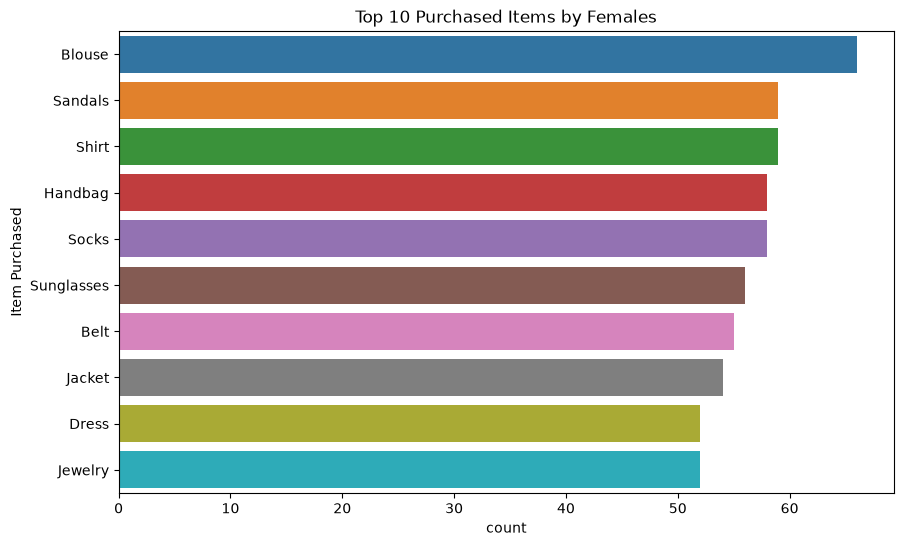

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_item_f.head(10),
    y='Item Purchased',
    x='count',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items by Females")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()


In [19]:
size_counts = df['Size'].value_counts()
size_counts


Size
M     1755
L     1053
S      663
XL     429
Name: count, dtype: int64

In [20]:
size_counts_m = male_df['Size'].value_counts()
size_counts_f = female_df['Size'].value_counts()

print("Male size counts:")
display(size_counts_m)

print("Female size counts:")
display(size_counts_f)


Male size counts:


Size
M     1165
L      716
S      476
XL     295
Name: count, dtype: int64

Female size counts:


Size
M     590
L     337
S     187
XL    134
Name: count, dtype: int64

### **Category**

In [21]:
ctg = df['Category'].value_counts().reset_index()
ctg


,Category,count
0,Clothing,1737
1,Accessories,1240
2,Footwear,599
3,Outerwear,324


In [22]:
ctg_m = male_df['Category'].value_counts().reset_index()
ctg_f = female_df['Category'].value_counts().reset_index()

print("Male categories:")
display(ctg_m)

print("Female categories:")
display(ctg_f)


Male categories:


,Category,count
0,Clothing,1181
1,Accessories,848
2,Footwear,400
3,Outerwear,223


Female categories:


,Category,count
0,Clothing,556
1,Accessories,392
2,Footwear,199
3,Outerwear,101


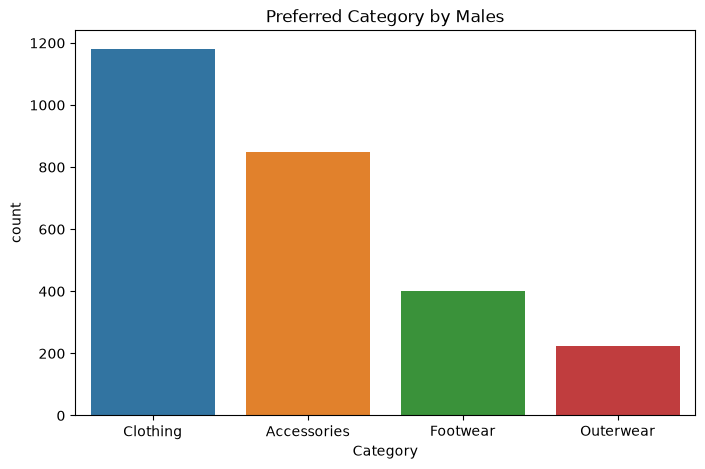

In [23]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg_m,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)
plt.title("Preferred Category by Males")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()


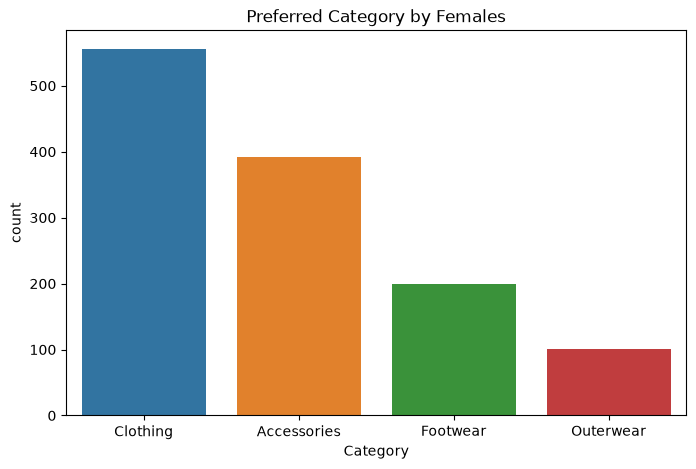

In [24]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg_f,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)
plt.title("Preferred Category by Females")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()


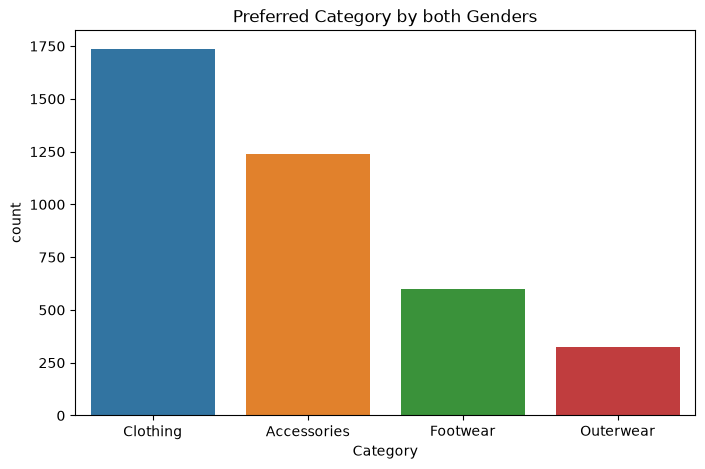

In [25]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)
plt.title("Preferred Category by both Genders")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()


In [26]:
waffle_data_m = dict(male_df['Category'].value_counts())
waffle_data_f = dict(female_df['Category'].value_counts())

waffle_data_m, waffle_data_f


({'Clothing': np.int64(1181),
  'Accessories': np.int64(848),
  'Footwear': np.int64(400),
  'Outerwear': np.int64(223)},
 {'Clothing': np.int64(556),
  'Accessories': np.int64(392),
  'Footwear': np.int64(199),
  'Outerwear': np.int64(101)})

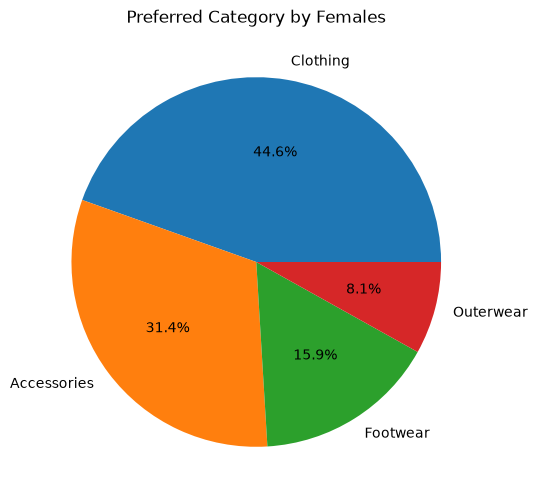

In [27]:
plt.figure(figsize=(6, 6))
plt.pie(
    waffle_data_f.values(),
    labels=waffle_data_f.keys(),
    autopct='%1.1f%%'
)
plt.title("Preferred Category by Females")
plt.show()


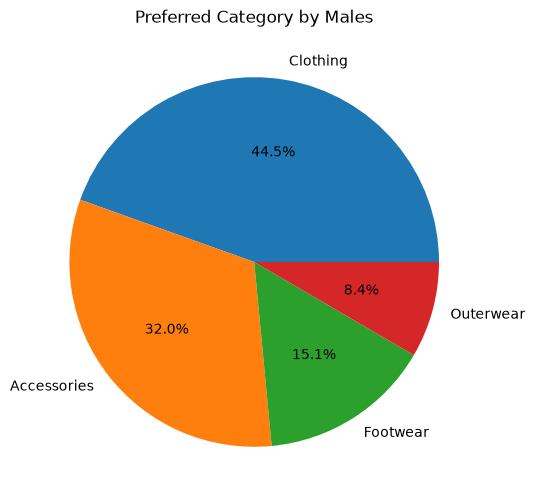

In [28]:
plt.figure(figsize=(6, 6))
plt.pie(
    waffle_data_m.values(),
    labels=waffle_data_m.keys(),
    autopct='%1.1f%%'
)
plt.title("Preferred Category by Males")
plt.show()


### **Review ratings**

In [29]:
cr_f = female_df[female_df['Category'] == 'Clothing']
avg_cr_f = cr_f['Review Rating'].mean()

avg_cr_f


np.float64(3.7044964028776977)

In [30]:
cr_m = male_df[male_df['Category'] == 'Clothing']
avg_cr_m = cr_m['Review Rating'].mean()

avg_cr_m


np.float64(3.7319220999153258)

In [31]:
avg_cr_m, avg_cr_f


(np.float64(3.7319220999153258), np.float64(3.7044964028776977))

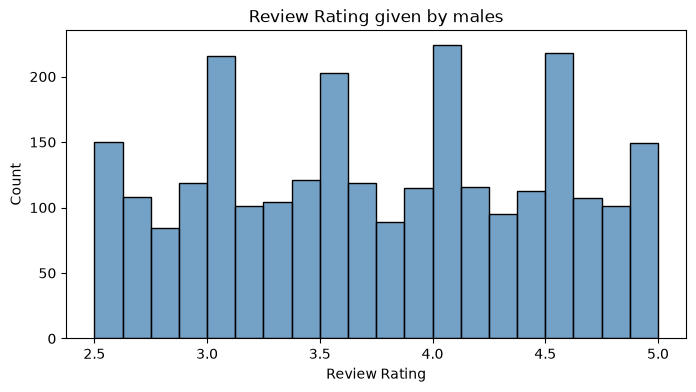

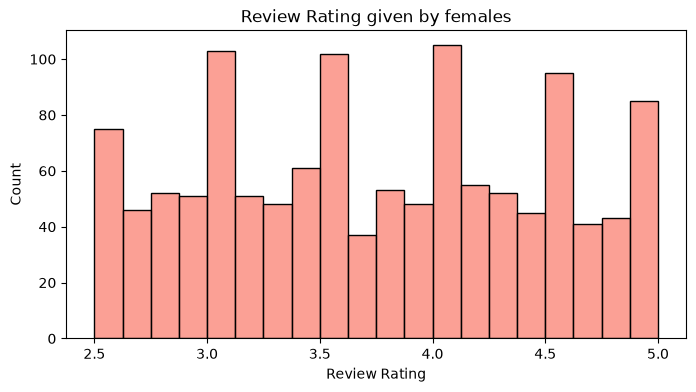

In [32]:
# males
plt.figure(figsize=(8, 4))
sns.histplot(data=male_df, x='Review Rating', bins=20, color='steelblue')
plt.title("Review Rating given by males")
plt.show()

# females
plt.figure(figsize=(8, 4))
sns.histplot(data=female_df, x='Review Rating', bins=20, color='salmon')
plt.title("Review Rating given by females")
plt.show()


In [33]:
cr_m['Review Rating'].value_counts().sort_index()


Review Rating
2.5    17
2.6    45
2.7    55
2.8    41
2.9    55
3.0    49
3.1    46
3.2    41
3.3    49
3.4    59
3.5    48
3.6    46
3.7    61
3.8    39
3.9    52
4.0    52
4.1    48
4.2    52
4.3    45
4.4    43
4.5    36
4.6    46
4.7    46
4.8    46
4.9    48
5.0    16
Name: count, dtype: int64

### **Purchase Amount (USD)**

In [34]:
m_tpa = male_df['Purchase Amount (USD)'].sum()
f_tpa = female_df['Purchase Amount (USD)'].sum()

m_tpa, f_tpa


(np.int64(157890), np.int64(75191))

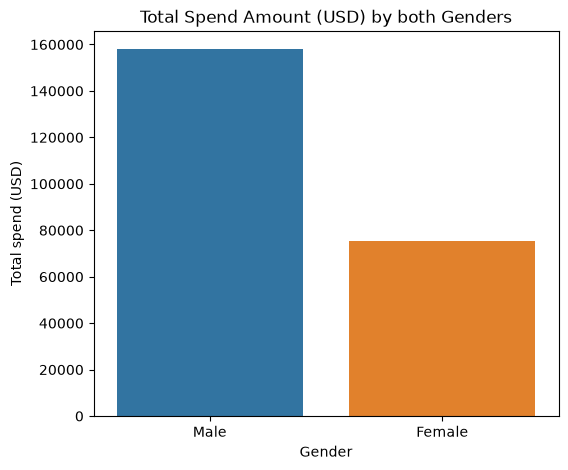

In [35]:
spend_by_gender = pd.DataFrame({
    'Gender': ['Male', 'Female'],
    'Total Spend (USD)': [m_tpa, f_tpa]
})

plt.figure(figsize=(6, 5))
sns.barplot(
    data=spend_by_gender,
    x='Gender',
    y='Total Spend (USD)',
    hue='Gender',
    dodge=False,
    legend=False
)
plt.title("Total Spend Amount (USD) by both Genders")
plt.ylabel('Total spend (USD)')
plt.show()


In [36]:
cc_f = cr_f
ca_f = female_df[female_df['Category'] == 'Accessories']
cf_f = female_df[female_df['Category'] == 'Footwear']
co_f = female_df[female_df['Category'] == 'Outerwear']

cc_f.shape, ca_f.shape, cf_f.shape, co_f.shape


((556, 18), (392, 18), (199, 18), (101, 18))

In [37]:
cc_m = cr_m
ca_m = male_df[male_df['Category'] == 'Accessories']
cf_m = male_df[male_df['Category'] == 'Footwear']
co_m = male_df[male_df['Category'] == 'Outerwear']

cc_m.shape, ca_m.shape, cf_m.shape, co_m.shape


((1181, 18), (848, 18), (400, 18), (223, 18))

In [38]:
pcu = dict(df['Promo Code Used'].value_counts())
pcu


{'No': np.int64(2223), 'Yes': np.int64(1677)}

### **Relationships (multivariate)**

Numeric columns only: Age, Purchase Amount (USD), Review Rating, Previous Purchases.

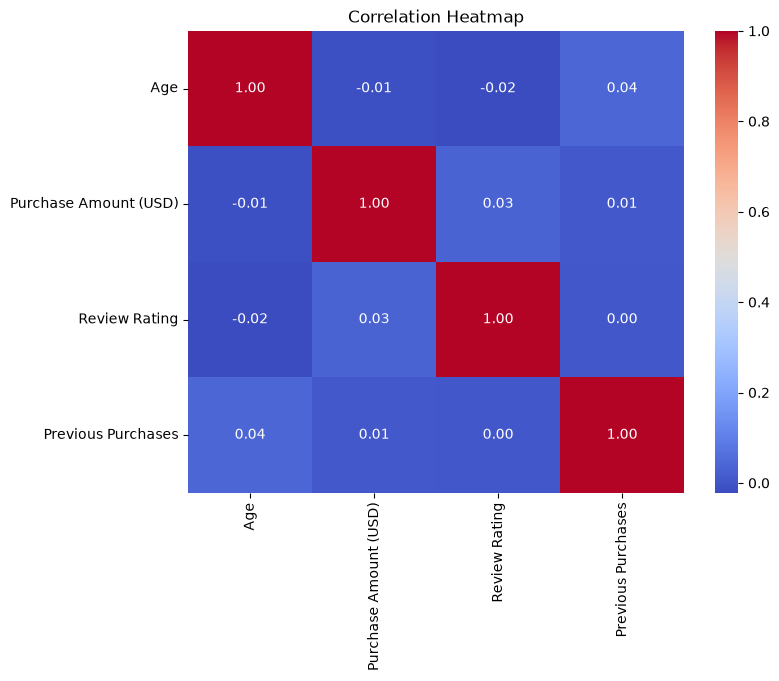

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
Age,1.000000,-0.010424,-0.021949,0.040445
Purchase Amount (USD),-0.010424,1.000000,0.030776,0.008063
Review Rating,-0.021949,0.030776,1.000000,0.004229
Previous Purchases,0.040445,0.008063,0.004229,1.000000


In [39]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

corr


### **Feature engineering**

Dummy variables for columns with few levels. Scale numeric columns (keep originals). Bin purchase amount.

In [40]:
df = pd.get_dummies(
    df,
    columns=['Gender', 'Size', 'Category'],
    dtype=int
)

df.head()


,Age,Item Purchased,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,...,Gender_Female,Gender_Male,Size_L,Size_M,Size_S,Size_XL,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear
0,55,Blouse,53,Kentucky,Gray,Winter,3.1,Yes,Credit Card,Express,...,0,1,1,0,0,0,0,1,0,0
1,19,Sweater,64,Maine,Maroon,Winter,3.1,Yes,Bank Transfer,Express,...,0,1,1,0,0,0,0,1,0,0
2,50,Jeans,73,Massachusetts,Maroon,Spring,3.1,Yes,Cash,Free Shipping,...,0,1,0,0,1,0,0,1,0,0
3,21,Sandals,90,Rhode Island,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,...,0,1,0,1,0,0,0,0,1,0
4,45,Blouse,49,Oregon,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,...,0,1,0,1,0,0,0,1,0,0


In [44]:
! pip install scikit-learn
from sklearn.preprocessing import MinMaxScaler, StandardScaler

minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()

df['Amount_minmax'] = minmax_scaler.fit_transform(
    df[['Purchase Amount (USD)']]
).ravel()

df['Age_standard'] = standard_scaler.fit_transform(
    df[['Age']]
).ravel()

df[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 28.6 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 53.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-learn] [scikit-learn]


,Purchase Amount (USD),Amount_minmax,Age,Age_standard
0,53,0.4125,55,0.718913
1,64,0.5500,19,-1.648629
2,73,0.6625,50,0.390088
3,90,0.8750,21,-1.517099
4,49,0.3625,45,0.061263


In [45]:
df['Amount_bin'] = pd.cut(
    df['Purchase Amount (USD)'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

df['Amount_bin'].value_counts()


Amount_bin
Low       1345
High      1297
Medium    1258
Name: count, dtype: int64

### **Summary**

Write 4–5 insights from the plots. These are associations, not causal claims.

Examples to check:
- Which items and categories are most common for males vs females?
- Do males and females spend a similar total amount?
- Is Review Rating similar across genders?
- How often is a promo code used?

### Insights from the data
- **Clothing** is the most common category for both genders: 1,181 male purchases and 556 female purchases.
- The most purchased item differs by gender: **Pants** is highest for males (123), while **Blouse** is highest for females (66).
- Total spending is **$157,890 for males** and **$75,191 for females**. This difference is strongly affected by the unequal number of observations (2,652 males vs. 1,248 females), so it should not be interpreted as males inherently spending more.
- Mean review ratings are very similar: about **3.75 for males** and **3.74 for females**. For Clothing only, the averages are also close (about 3.73 vs. 3.70).
- Promo codes were used in **1,677 of 3,900 purchases (43%)**; 57% of purchases did not use a promo code.
- Correlations among Age, Purchase Amount, Review Rating, and Previous Purchases are all very weak in this dataset.

Caveat: correlation is not causation.
